# 🧠🤖 第4周-Day2：向量检索：Embedding 与相似度计算

## 📚 学习目标
今天我们要深入理解向量检索的核心技术——Embedding和相似度计算，这是RAG系统的基础！

### 🎯 主要内容
1. 什么是Embedding？
2. 向量空间的概念
3. 相似度计算方法
4. 实战代码演示
5. 业务应用场景

## 🔍 什么是Embedding？

Embedding（嵌入）是一种将离散符号（如文字、图片）转换为连续向量的技术。想象一下：

🎯 **核心思想**：将语义相关的文本映射到向量空间中相近的位置

📊 **可视化理解**：
- "机器学习"和"深度学习" → 距离很近
- "猫咪"和"狗" → 中等距离
- "苹果"和"手机" → 距离较远

💡 **关键特性**：
- 固定维度的向量（通常768维、1024维等）
- 语义相近 → 向量距离相近
- 支持数学运算（相似度计算、向量运算）

使用字体: Noto Sans CJK JP


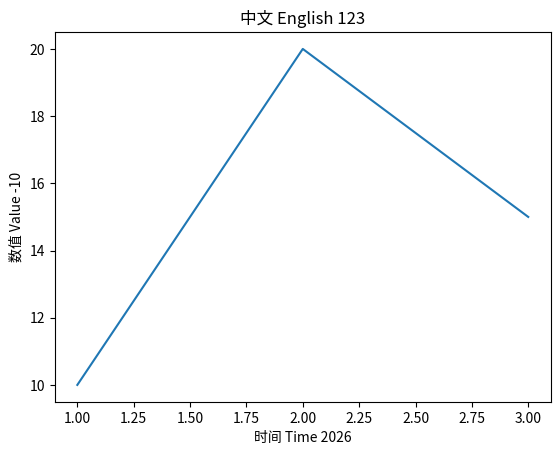

📊 示例向量表示：
机器学习: [0.8 0.6 0.2 0.1]
深度学习: [0.7 0.5 0.3 0.2]
猫咪: [0.2 0.8 0.1 0.9]
狗: [0.3 0.7 0.2 0.8]
苹果: [0.9 0.1 0.8 0.2]
手机: [0.1 0.9 0.3 0.7]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

# 设置中文字体
from matplotlib import font_manager
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("使用字体:", font_name)

plt.title("中文 English 123")
plt.xlabel("时间 Time 2026")
plt.ylabel("数值 Value -10")
plt.plot([1, 2, 3], [10, 20, 15])
plt.show()

# 创建一些示例向量（模拟embedding）
vectors = {
    "机器学习": np.array([0.8, 0.6, 0.2, 0.1]),
    "深度学习": np.array([0.7, 0.5, 0.3, 0.2]),
    "猫咪": np.array([0.2, 0.8, 0.1, 0.9]),
    "狗": np.array([0.3, 0.7, 0.2, 0.8]),
    "苹果": np.array([0.9, 0.1, 0.8, 0.2]),
    "手机": np.array([0.1, 0.9, 0.3, 0.7])
}

print("📊 示例向量表示：")
for key, vec in vectors.items():
    print(f"{key}: {vec}")

## 📐 向量空间与相似度计算

### 🔸 常用相似度计算方法

1. **余弦相似度** (Cosine Similarity)
   - 计算向量夹角的余弦值
   - 值域：[-1, 1]，越接近1越相似
   - 适合文本语义相似度

2. **欧几里得距离** (Euclidean Distance)
   - 计算向量之间的直线距离
   - 值域：[0, ∞)，越小越相似
   - 适合数值型数据

3. **点积** (Dot Product)
   - 向量对应元素相乘后求和
   - 值域：[-∞, ∞]，越大越相似
   - 计算效率高

In [9]:
# 定义相似度计算函数
def cosine_sim(vec1, vec2):
    """计算余弦相似度"""
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    return dot_product / (norm1 * norm2)

def euclidean_dist(vec1, vec2):
    """计算欧几里得距离"""
    return np.linalg.norm(vec1 - vec2)

def dot_product(vec1, vec2):
    """计算点积"""
    return np.dot(vec1, vec2)

# 计算所有向量对的相似度
texts = list(vectors.keys())
cosine_matrix = np.zeros((len(texts), len(texts)))
euclidean_matrix = np.zeros((len(texts), len(texts)))
dot_matrix = np.zeros((len(texts), len(texts)))

for i in range(len(texts)):
    for j in range(len(texts)):
        cosine_matrix[i, j] = cosine_sim(vectors[texts[i]], vectors[texts[j]])
        euclidean_matrix[i, j] = euclidean_dist(vectors[texts[i]], vectors[texts[j]])
        dot_matrix[i, j] = dot_product(vectors[texts[i]], vectors[texts[j]])

print("📊 余弦相似度矩阵：")
print(cosine_matrix)
print("\n📊 欧几里得距离矩阵：")
print(euclidean_matrix)
print("\n📊 点积矩阵：")
print(dot_matrix)

📊 余弦相似度矩阵：
[[1.         0.98349822 0.5976143  0.67813269 0.76494631 0.61858957]
 [0.98349822 1.         0.65653216 0.74498873 0.84036117 0.67957535]
 [0.5976143  0.65653216 1.         0.98925444 0.34666667 0.96609178]
 [0.67813269 0.74498873 0.98925444 1.         0.48007936 0.96374176]
 [0.76494631 0.84036117 0.34666667 0.48007936 1.         0.38643671]
 [0.61858957 0.67957535 0.96609178 0.96374176 0.38643671 1.        ]]

📊 欧几里得距离矩阵：
[[0.         0.2        1.02469508 0.8660254  0.79372539 0.97467943]
 [0.2        0.         0.93273791 0.75498344 0.67082039 0.87749644]
 [1.02469508 0.93273791 0.         0.2        1.4        0.31622777]
 [0.8660254  0.75498344 0.2        0.         1.2        0.31622777]
 [0.79372539 0.67082039 1.4        1.2        0.         1.33416641]
 [0.97467943 0.87749644 0.31622777 0.31622777 1.33416641 0.        ]]

📊 点积矩阵：
[[1.05 0.94 0.75 0.78 0.96 0.75]
 [0.94 0.87 0.75 0.78 0.96 0.75]
 [0.75 0.75 1.5  1.36 0.52 1.4 ]
 [0.78 0.78 1.36 1.26 0.66 1.28]
 [0.9

## 📈 可视化相似度结果

让我们用热力图直观展示不同文本之间的相似度关系！

/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.print_figure(bytes_io, **kw)


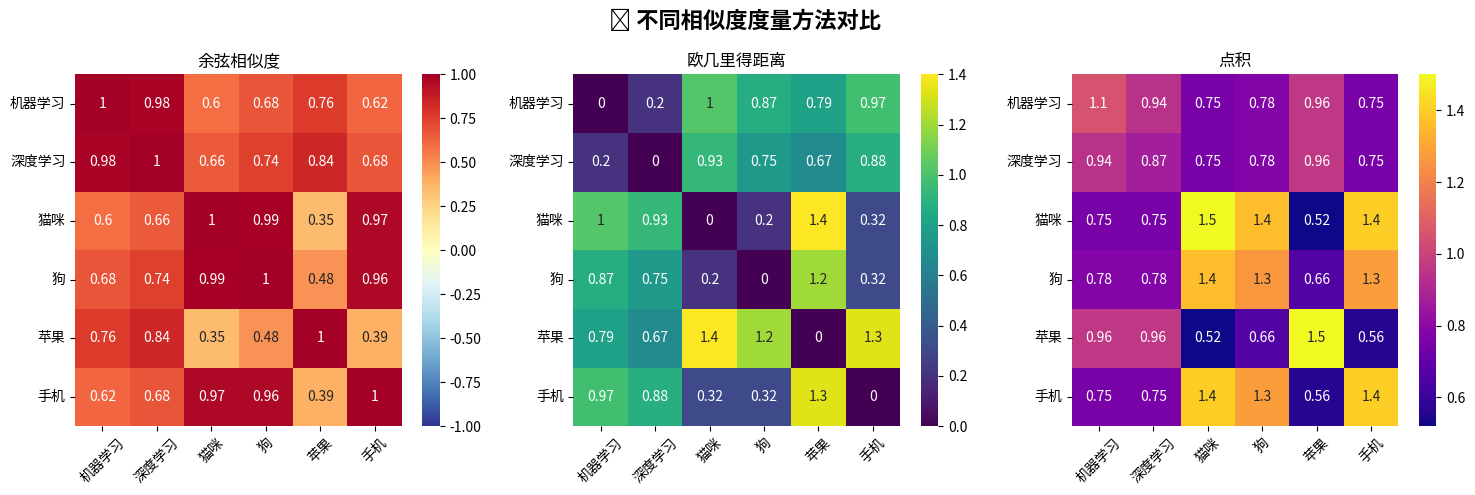

🎯 关键观察：
• 余弦相似度：语义相似的文本值较高（颜色偏红）
• 欧几里得距离：语义相似的文本值较小（颜色偏深蓝）
• 点积：语义相似的文本值较大（颜色偏黄/白）


In [10]:
# 创建热力图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('📈 不同相似度度量方法对比', fontsize=16, fontweight='bold')

# 余弦相似度
sns.heatmap(cosine_matrix, annot=True, cmap='RdYlBu_r', ax=axes[0], 
            xticklabels=texts, yticklabels=texts, vmin=-1, vmax=1)
axes[0].set_title('余弦相似度')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# 欧几里得距离
sns.heatmap(euclidean_matrix, annot=True, cmap='viridis', ax=axes[1], 
            xticklabels=texts, yticklabels=texts)
axes[1].set_title('欧几里得距离')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

# 点积
sns.heatmap(dot_matrix, annot=True, cmap='plasma', ax=axes[2], 
            xticklabels=texts, yticklabels=texts)
axes[2].set_title('点积')
axes[2].tick_params(axis='x', rotation=45)
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print("🎯 关键观察：")
print("• 余弦相似度：语义相似的文本值较高（颜色偏红）")
print("• 欧几里得距离：语义相似的文本值较小（颜色偏深蓝）")
print("• 点积：语义相似的文本值较大（颜色偏黄/白）")

## 🚀 实战：使用真实的Embedding模型

现在让我们使用HuggingFace的Sentence Transformers来生成真实的embedding！

In [11]:
# 安装必要的包
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# 安装sentence-transformers
try:
    from sentence_transformers import SentenceTransformer, util
    print("✅ Sentence Transformers 已安装")
except ImportError:
    print("🔄 正在安装 Sentence Transformers...")
    install_package('sentence-transformers')
    from sentence_transformers import SentenceTransformer, util

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


✅ Sentence Transformers 已安装


In [12]:
# 加载预训练模型
model_name = 'paraphrase-multilingual-MiniLM-L12-v2'  # 多语言模型
model = SentenceTransformer(model_name)

# 要编码的文本
sentences = [
    "机器学习是人工智能的重要分支",
    "深度学习属于机器学习的子集",
    "我喜欢喝糖水",
    "美华糖水店的芋圆很好吃",
    "Python是一种编程语言",
    "Java是另一种编程语言",
    "我今天想喝奶茶",
    "天气预报说明天会下雨"
]

print("📝 编码文本列表：")
for i, sentence in enumerate(sentences):
    print(f"{i+1}. {sentence}")

# 生成embedding
embeddings = model.encode(sentences)

print(f"\n📊 Embedding形状：{embeddings.shape}")
print(f"每句话都被表示为{embeddings.shape[1]}维向量")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

📝 编码文本列表：
1. 机器学习是人工智能的重要分支
2. 深度学习属于机器学习的子集
3. 我喜欢喝糖水
4. 美华糖水店的芋圆很好吃
5. Python是一种编程语言
6. Java是另一种编程语言
7. 我今天想喝奶茶
8. 天气预报说明天会下雨

📊 Embedding形状：(8, 384)
每句话都被表示为384维向量


In [14]:
# 计算余弦相似度
cosine_sim_matrix = util.cos_sim(embeddings, embeddings)

# 创建相似度矩阵DataFrame
import pandas as pd
sim_df = pd.DataFrame(cosine_sim_matrix.numpy(), 
                     index=sentences, 
                     columns=sentences)

print("📜 实际Embedding的余弦相似度矩阵：")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(sim_df)

# 找出最相似的句子对
max_sim = 0
best_pair = ("", "")

for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        if cosine_sim_matrix[i, j] > max_sim:
            max_sim = cosine_sim_matrix[i, j]
            best_pair = (sentences[i], sentences[j])

print(f"\n🎯 最相似的句子对：")
print(f"'{best_pair[0]}' 和 '{best_pair[1]}'")
print(f"相似度：{max_sim:.4f}")

📜 实际Embedding的余弦相似度矩阵：
                机器学习是人工智能的重要分支  深度学习属于机器学习的子集    我喜欢喝糖水  美华糖水店的芋圆很好吃  \
机器学习是人工智能的重要分支        1.000000       0.751198 -0.001399     0.006046   
深度学习属于机器学习的子集         0.751198       1.000000 -0.032188     0.014211   
我喜欢喝糖水               -0.001399      -0.032188  1.000000     0.476423   
美华糖水店的芋圆很好吃           0.006046       0.014211  0.476423     1.000000   
Python是一种编程语言         0.087235       0.055250  0.020489    -0.073887   
Java是另一种编程语言          0.138735       0.084942  0.151170     0.034275   
我今天想喝奶茶              -0.062929      -0.044009  0.580254     0.348748   
天气预报说明天会下雨            0.041708       0.011209  0.112956     0.121839   

                Python是一种编程语言  Java是另一种编程语言   我今天想喝奶茶  天气预报说明天会下雨  
机器学习是人工智能的重要分支       0.087235      0.138735 -0.062929    0.041708  
深度学习属于机器学习的子集        0.055250      0.084942 -0.044009    0.011209  
我喜欢喝糖水               0.020489      0.151170  0.580254    0.112956  
美华糖水店的芋圆很好吃         -0.073887      0.034275  0.348748   

## 🎯 RAG中的向量检索实战

在RAG系统中，向量检索通常包括以下步骤：

1. **Query Encoding** - 将用户查询转换为embedding
2. **Similarity Search** - 在向量数据库中搜索最相似的文档
3. **Ranking** - 按相似度排序并返回最相关的结果

In [16]:
# 模拟RAG检索过程
def rag_search(query, documents, embeddings, top_k=3):
    """RAG检索函数"""
    # 编码查询
    query_embedding = model.encode([query])
    
    # 计算查询与所有文档的相似度
    query_similarities = util.cos_sim(query_embedding, embeddings)[0]
    
    # 将Tensor转为NumPy数组后再排序
    sim_array = query_similarities.numpy()
    
    # 获取top_k个最相似的文档
    top_indices = np.argsort(sim_array)[-top_k:][::-1]
    
    # 返回结果
    results = []
    for idx in top_indices:
        results.append({
            'document': documents[idx],
            'similarity': float(sim_array[idx]),
            'index': idx
        })
    
    return results

# 测试查询
test_query = "我想喝糖水，有什么推荐的吗？"

print(f"🔍 用户查询：{test_query}")
print("\n📋 检索到的最相关文档：")
results = rag_search(test_query, sentences, embeddings)

for i, result in enumerate(results, 1):
    print(f"{i}. 相似度：{result['similarity']:.4f}")
    print(f"   文档：{result['document']}")
    print()

🔍 用户查询：我想喝糖水，有什么推荐的吗？

📋 检索到的最相关文档：
1. 相似度：0.8538
   文档：我喜欢喝糖水

2. 相似度：0.6166
   文档：我今天想喝奶茶

3. 相似度：0.4697
   文档：美华糖水店的芋圆很好吃



## 💡 业务应用场景：美华糖水店

让我们看看embedding技术如何应用到美华糖水店的业务中：

In [18]:
# 模拟不同的顾客查询
customer_queries = [
    "我想喝甜的",
    "今天天气热，想要解暑的",
    "我喜欢喝茶",
    "推荐一个招牌的",
    "我想喝奶茶类的"
]

print("\n" + "="*60)
print("🎯 智能推荐系统演示：")
print("="*60)

for query in customer_queries:
    print(f"\n👤 顾客：{query}")
    
    # 检索推荐
    query_embedding = model.encode([query])
    similarities = util.cos_sim(query_embedding, menu_embeddings)[0]
    
    # 将Tensor转为NumPy数组后再排序
    sim_array = similarities.numpy()
    
    # 获取top 3推荐
    top_indices = np.argsort(sim_array)[-3:][::-1]
    
    print("💡 推荐结果：")
    for idx in top_indices:
        print(f"   • {menu_items[idx]} (相似度: {sim_array[idx]:.3f})")


🎯 智能推荐系统演示：

👤 顾客：我想喝甜的
💡 推荐结果：
   • 柠檬茶，清爽柠檬茶 (相似度: 0.620)
   • 招牌芋圆奶茶，香浓奶茶配Q弹芋圆 (相似度: 0.576)
   • 珍珠奶茶，经典珍珠奶茶 (相似度: 0.551)

👤 顾客：今天天气热，想要解暑的
💡 推荐结果：
   • 绿豆沙，清热解暑绿豆沙 (相似度: 0.564)
   • 红豆冰，传统经典红豆冰沙 (相似度: 0.350)
   • 招牌芋圆奶茶，香浓奶茶配Q弹芋圆 (相似度: 0.295)

👤 顾客：我喜欢喝茶
💡 推荐结果：
   • 奶盖茶，茶叶配奶盖 (相似度: 0.665)
   • 柠檬茶，清爽柠檬茶 (相似度: 0.576)
   • 珍珠奶茶，经典珍珠奶茶 (相似度: 0.546)

👤 顾客：推荐一个招牌的
💡 推荐结果：
   • 招牌芋圆奶茶，香浓奶茶配Q弹芋圆 (相似度: 0.443)
   • 布丁，鸡蛋布丁 (相似度: 0.353)
   • 西瓜汁，新鲜西瓜汁 (相似度: 0.327)

👤 顾客：我想喝奶茶类的
💡 推荐结果：
   • 奶盖茶，茶叶配奶盖 (相似度: 0.754)
   • 珍珠奶茶，经典珍珠奶茶 (相似度: 0.686)
   • 招牌芋圆奶茶，香浓奶茶配Q弹芋圆 (相似度: 0.686)


## 🧩 课堂练习答案

1. "机器学习"和"深度学习"的embedding相似度预计是？**高**（都是AI领域相关术语）
2. "猫咪"和"狗"的embedding相似度预计是？**中等**（都是动物但不同种类）
3. 余弦相似度值域范围是？**[-1, 1]**，1表示完全相同，-1表示完全相反

## 📝 课后测试答案

❶ B. 余弦相似度（最适合文本语义相似度）

❷ A. 完全相同（余弦相似度为1表示向量方向完全一致）

❸ C. 很高（>0.7）（"Hello"和"Hi"是近义词，语义高度相似）

❸ B. 理解语义（向量检索能理解语义关系，不依赖关键词）

❷ C. 蛇类动物（语义最不相关）

## 🎯 下节预告
明天我们将学习高级RAG技术，包括混合检索、重排序和查询改写，让我们的检索系统更加强大！

In [19]:
# 总结：向量检索的关键要点
print("🎯 第4周-Day2 学习总结：")
print("=" * 50)
print("✅ Embedding技术将文本转换为高维向量")
print("✅ 向量空间中语义相近的文本距离更近")
print("✅ 余弦相似度是最常用的文本相似度度量")
print("✅ 向量检索实现语义理解，超越关键词匹配")
print("✅ 在RAG系统中，向量检索是核心组成部分")
print("✅ 实际应用：智能推荐、搜索问答、文档检索")
print("=" * 50)
print("\n🚀 准备好迎接明天的高级RAG技术了吗？")

🎯 第4周-Day2 学习总结：
✅ Embedding技术将文本转换为高维向量
✅ 向量空间中语义相近的文本距离更近
✅ 余弦相似度是最常用的文本相似度度量
✅ 向量检索实现语义理解，超越关键词匹配
✅ 在RAG系统中，向量检索是核心组成部分
✅ 实际应用：智能推荐、搜索问答、文档检索

🚀 准备好迎接明天的高级RAG技术了吗？
